<div align="center">
    <img src="images/TBM3D/tbm1.png" width="1300">
</div>

3D TBM is used for 3D image analysis and consists of 4 parts: 

Step 1: Pre-processing & preparation for TBM

Step 2: Computing the transport embedding 

Step 3: Statistical analysis

step 4: Visualization

<font size="5">Step 1: Pre-processing & preparation for TBM</font>

Before running the TBM codes, you should prepare your data(i.e. registratoin, segmentation, centralization...).
After preprocessing, all the training and testing images should be numpy files (endwith .npy) with same shape ([h,w,d])

All the training and testing data should be organized in a csv file separately(one file for training, one file for testing), the structure of this file should be like:

    image_path      | label | other variable...
    ./data/0.npy    |   1   | ...
    ./data/1.npy    |   0   | ...
    ...

where the 'image_path' can be read directly, 'label' is the corresponding label. You can organize other variables related to the data into this file, but we don’t need them here.


In this demo program, we have already preprocessed all the data. You can download it using the following link and then extract it to the current directory:

https://drive.google.com/file/d/14K-Q5PzkiFzEUMxDb0984QWIB2VkWpda/view?usp=drive_link

<font size="5">Step 2: Computing the transport embedding </font>

After preparing the data, you only need to set the corresponding file path and then you can start running our program. If you can provide the reference, please set the path of reference, the reference should have same shape as images; otherwise, we will use the average of all training images as the reference. And if you already did normalization, set 'normalized = True', otherwise, we will do normalization when loading data.

\* Usually, the normalization[1] is 

$$\sum_x I_i(\textbf{x}) = 1, \ i= 1,...,N$$
<!-- <math xmlns="http://www.w3.org/1998/Math/MathML" display="block" id="m1" overflow="scroll" alttext="No alternative text available"><mrow><munder><mo stretchy="true">∫</mo><mi mathvariant="normal">Ω</mi></munder><mo>‍</mo><msub><mi>I</mi><mi>i</mi></msub><mrow><mo stretchy="false">(</mo><mi mathvariant="bold">x</mi><mo stretchy="false">)</mo></mrow><mi>d</mi><mi mathvariant="bold">x</mi><mo>=</mo><mn>1</mn></mrow></math> -->
But for ease of calculation, we need to add a small amount of mass to the background.

In [9]:
from pytranskit.TBM3D.image_processing import load_data
import numpy as np
train_file_path = './IXI_data/train.csv'
test_file_path = './IXI_data/test.csv'
reference_path = None
normalized = False

train_images, train_labels, reference = load_data(file_path=train_file_path, reference_path=reference_path, normalized=normalized, mode = 'train')
test_images, test_labels = load_data(file_path=test_file_path, normalized=normalized, mode = 'test')
np.save('./IXI_data/cla_train_template.npy', reference)

<!-- <div align="center">
    <img src="part1.png" width="300">
</div> -->


The optimal transport is solving the following problem:

$$f^*_i(\textbf{x}) = \arg \min_{f_i} \int |\textbf{x}-f_i(\textbf{x})|^2I_0(\textbf{x})d\textbf{x},$$

$$ s.t.\ det(Df_i(\textbf{x}))
    I_i(f_i(\textbf{x})) = I_0(\textbf{x})$$

<!-- <math xmlns="http://www.w3.org/1998/Math/MathML" display="block" id="m2" overflow="scroll" alttext="No alternative text available"><mrow><mtable><mtr><mtd><msubsup><mi>f</mi><mi>i</mi><mo>*</mo></msubsup><mrow><mo stretchy="false">(</mo><mi mathvariant="bold">x</mi><mo stretchy="false">)</mo></mrow><mo>=</mo><munder><mrow><mtext>arg</mtext><mtext>min</mtext></mrow><mrow><msub><mi>f</mi><mi>i</mi></msub><mo>∈</mo><mtext>MP</mtext></mrow></munder><munder><mo stretchy="true">∫</mo><mi mathvariant="normal">Ω</mi></munder><mrow><mo stretchy="false">∣</mo><mi mathvariant="bold">x</mi></mrow><mo>−</mo><msub><mi>f</mi><mi>i</mi></msub><msup><mrow><mo stretchy="false">(</mo><mi mathvariant="bold">x</mi><mo stretchy="false">)</mo><mo stretchy="false">∣</mo></mrow><mn>2</mn></msup><msub><mi>I</mi><mn>0</mn></msub><mrow><mo stretchy="false">(</mo><mi mathvariant="bold">x</mi><mo stretchy="false">)</mo></mrow><mi>d</mi><mi mathvariant="bold">x</mi></mtd></mtr><mtr><mtd><mtext>such that det</mtext><mrow><mo stretchy="false">(</mo><mi>D</mi><mo>&nbsp;</mo><msub><mi>f</mi><mi>i</mi></msub><mrow><mo stretchy="false">(</mo><mi mathvariant="bold">x</mi><mo stretchy="false">)</mo></mrow><mo stretchy="false">)</mo></mrow><msub><mi>I</mi><mi>i</mi></msub><mrow><mo stretchy="false">(</mo><msub><mi>f</mi><mi>i</mi></msub><mrow><mo stretchy="false">(</mo><mi mathvariant="bold">x</mi><mo stretchy="false">)</mo></mrow><mo stretchy="false">)</mo></mrow><mo mathvariant="bold">=</mo><msub><mi>I</mi><mn>0</mn></msub><mrow><mo stretchy="false">(</mo><mi mathvariant="bold">x</mi><mo stretchy="false">)</mo></mrow><mo>&nbsp;</mo><mo>∀</mo><mi mathvariant="bold">x</mi><mo>∈</mo><mi mathvariant="normal">Ω</mi></mtd></mtr></mtable></mrow></math> -->

Here, $D$ denotes the Jacobian matrix, and the $MP$ is the family of all mass-preserving mappings from $I_0$ to $I_1$. Here, $f_i : Ω ⟶ Ω$ is a mass preserving mapping from $I_0$ to $I_i$. The OT mapping is calculated from the reference image $I_0$.

The transport map $f_i^*(x)$ is the embeding of $I_i$ in the transport space.


[1] Kundu, Shinjini, et al. "Discovering the gene-brain-behavior link in autism via generative machine learning." Science advances 10.24 (2024): eadl5307.

[2] Ironside Natasha, El Naamani Kareem, Rizvi Tanvir, E-Rabbi Mohammed Shifat, Kundu Shinjini, Becceril-Gaitan Andrea, Pas Kristofor, Snyder Harrison, Chen Ching-Jen, Langefeld Carl D, Woo Daniel, Mayer Stephan, Connolly E Sander, Rohde Gustavo, ERICH Investigators and the VISTA-ICH collaboration  (2025) Predictive modeling of hematoma expansion from non-contrast computed tomography in spontaneous intracerebral hemorrhage patients eLife 14:RP105782

Use the following function to calculate optimal transport maps. $TBM\_forward()$ will return a list, each element of the list corresponds to the calculation result of each image, including transport maps, MSE and other values. For more information, please refer to the function description. To facilitate the subsequent function calls (PCA, PLDA...), $process\_features()$ will convert the transport maps into n\*d numpy arrays, what we do here is: $(f-I_d)*\sqrt{I_0}$, where $f$ is the transport map, $I_d$ is identity function, $I_0$ is the reference.

\*However, for 3D medical image data, the calculation process may take a long time. Therefore, we strongly recommend storing the results for future use. Just fill in the storage path in train_maps_folder and test_maps_folder (if it is not filled in or None, maps will not be stored). 

In [ ]:
from pytranskit.TBM3D.TBM_forward import TBM3D_forward, process_features
train_maps_folder = './IXI_data/train_maps'
test_maps_folder = './IXI_data/test_maps'
train_results = TBM3D_forward(train_images, train_labels, reference, output_folder = train_maps_folder, parallel = True, num_workers = 12)
train_features, train_labels = process_features(train_results,reference)
test_results = TBM3D_forward(test_images, test_labels, reference, output_folder = test_maps_folder, parallel = True, num_workers = 12)
test_features, test_labels = process_features(test_results,reference)


If you already have transport maps from previous function, you can read them as follows.

In [ ]:
from pytranskit.TBM3D.TBM_forward import read_features, process_features
import numpy as np

reference = np.load('./IXI_data/cla_train_template.npy')

train_maps_folder = './IXI_data/train_maps'
test_maps_folder = './IXI_data/test_maps'
train_results = read_features(train_maps_folder)
train_features, train_labels = process_features(train_results,reference)
test_results = read_features(test_maps_folder)
test_features, test_labels = process_features(test_results,reference)

If you are interested in the transport maps you get, you can use the following function to visualize them. (We just show 1 example here)

The second line visualizes the geodesic from from $I_1$ to $I_0$ by:

$$ I_\alpha(x) = (D_{f_\alpha}(x))'I_1(f_\alpha(x)), \ \ f_{\alpha} = (1- \alpha)* I_d + \alpha f_i^*$$

where $I_d$ is the identity function.

In [ ]:
from pytranskit.TBM3D.visualization import *
visualize_result(train_results[1])

This is an interactive program; after running it, you will see results similar to the following:

<div align="center">
    <img src="images/TBM3D/v1.png" width="1300">
</div>

<div align="center">
    <img src="images/TBM3D/v2.png" width="1300">
</div>

<font size="5">Step 3 & 4: Statistical analysis & Visualization</font>

PCA is used to reduce the dimensionality of the features.

In [ ]:
from pytranskit.TBM3D.pca_tbm3d import SimplePCA
# train_features, test_features obtained from process_features()
# n_components: precentage of explained variance
pca = SimplePCA(n_components=0.96)
X_train_pca = pca.fit_transform(train_features)
X_test_pca = pca.transform(test_features)

Visualizing the results of PCA helps to observe the distribution and characteristics of the data. The following function can be used to observe the projection of data on the first 2 PCA directions and the corresponding data changes of each PCA component(set mode to corresponding component number, from 0 to pca.n_componets\_-1).

/home/honeyk/project/Github/PyTransKit/pytranskit/TBM3D/visualization.py:214: RuntimeWarning: invalid value encountered in divide
  X_inverse_maps = X_inverse_maps/np.sqrt(reference)


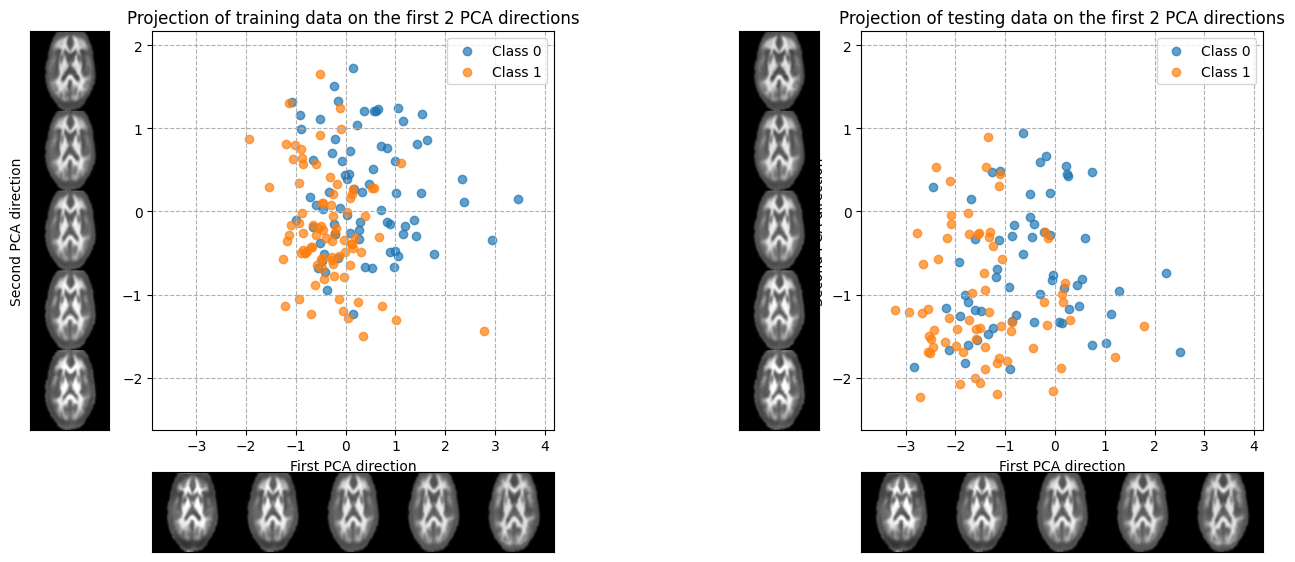

interactive(children=(IntSlider(value=48, description='Slice', max=95), Output()), _dom_classes=('widget-inter…

In [4]:
from pytranskit.TBM3D.visualization import *
# mode: corresponding component number, from 0 to pca.n_componets_-1
images = visualize_pca(X_train_pca,X_test_pca,train_labels,test_labels,reference, pca, modes = [0])

Train a PLDA classifier.

[3] Wang, Wei, et al. "Penalized fisher discriminant analysis and its application to image-based morphometry." Pattern recognition letters 32.15 (2011): 2128-2135.

In [5]:
from pytranskit.optrans.decomposition import PLDA
from pytranskit.TBM3D.gradient import calculate_alpha
alpha = calculate_alpha(X_train_pca, pca.components_.T, train_labels)
plda=PLDA(alpha=alpha,n_components=None)
plda_proj_tr = plda.fit_transform(X_train_pca,train_labels)[:,0]
plda_proj_te = plda.transform(X_test_pca)[:,0]


Confusion metrix and ROC 

\*This is only for binary classification. If it is multi-classification, you can change it to a suitable evaluation indicator.

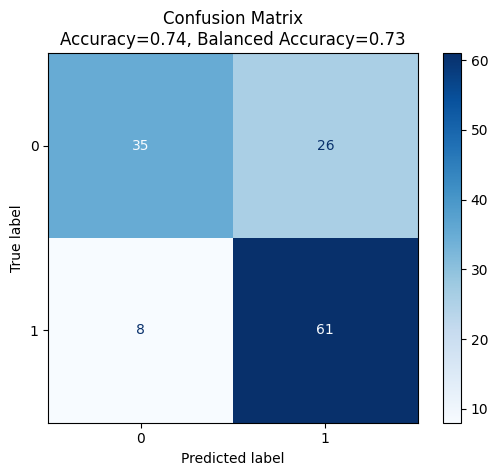

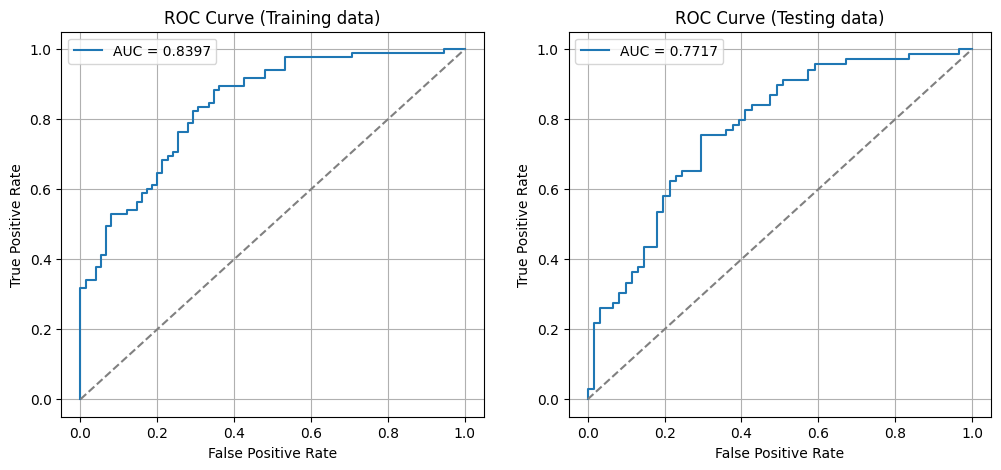

0.77167973390354

In [7]:
from pytranskit.TBM3D.visualization import *
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score
import matplotlib.pyplot as plt

predict_scores = plda.predict(X_test_pca)
acc = accuracy_score(test_labels, predict_scores)
bal_acc = balanced_accuracy_score(test_labels, predict_scores)
cm = confusion_matrix(test_labels, predict_scores)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix\nAccuracy={acc:.2f}, Balanced Accuracy={bal_acc:.2f}")
plt.show()
visual_roc(plda_proj_tr,train_labels,plda_proj_te,test_labels)

Discrimination of images by PLDA

Generates 5 images in series with less to more likelihood of the discriminant tested (i.e. less and more hematoma expansion).

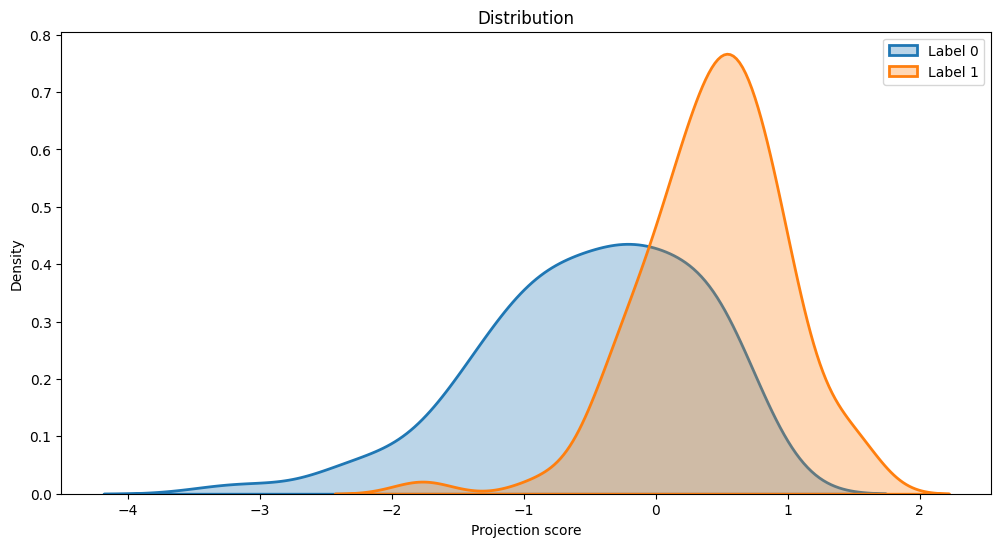

/home/honeyk/project/Github/PyTransKit/pytranskit/TBM3D/visualization.py:214: RuntimeWarning: invalid value encountered in divide
  X_inverse_maps = X_inverse_maps/np.sqrt(reference)


interactive(children=(IntSlider(value=48, description='Slice', max=95), Output()), _dom_classes=('widget-inter…

In [8]:
images = inverse_visualiztion(plda_proj_tr,train_labels,reference,plda,pca)

The visualization of PLDA will look like this:

<div align="center">
    <img src="images/TBM3D/plda.png" width="1300">
</div>